# Verification and Validation

After generating synthetic flows, two questions follow (Stedinger and
Taylor, 1982):

- **Verification**: does the ensemble reproduce the statistics the
  generator was designed to reproduce (moments, correlations,
  distributional shape)?
- **Validation**: does the ensemble reproduce characteristics the
  generator was not explicitly fit to, such as drought duration and
  severity?

`synhydro.verify` and `synhydro.validate` answer these with the same
reporting idiom: each statistic is computed once on the observed record
and once on every realization, and the observed value is compared
against the distribution of the statistic across realizations.

> **Note:** Run this notebook from the `examples/` directory. Figures are saved to `figures/05_verification/` and data outputs to `outputs/05_verification/` (both are gitignored).

In [1]:
from pathlib import Path

FIG_DIR = Path("figures") / "05_verification"
OUT_DIR = Path("outputs") / "05_verification"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Setup

In [2]:
import synhydro

Q_daily = synhydro.load_example_data()
Q_monthly = Q_daily.resample("MS").sum()

gen = synhydro.KirschGenerator()
gen.fit(Q_monthly)
ensemble = gen.generate(n_realizations=100, n_years=50, seed=42)

## Run verification

Metric selection is explicit: pass `metrics="all"`, or a list of
category names, metric names, and callables. Categories:
`marginal`, `temporal`, `seasonal`, `annual`, `spatial`, `fdc`,
`lmoments`, `extremes`, `spectral`. See the
[verification API reference](../../api/verification/) for the full
metric table with citations.

In [3]:
result = synhydro.verify(ensemble, Q_monthly, metrics="all")

Or select specific categories and metrics:

In [4]:
result_subset = synhydro.verify(
    ensemble, Q_monthly,
    metrics=["marginal", "seasonal", "acf"],
)

## Read the summary

`result.summary()` returns one row per metric (and per component for
curve metrics such as monthly means), with the observed value, the
spread across realizations, and two consistency measures:

- `obs_percentile`: the observed value's position within the synthetic
  sample, `(n_below + 0.5 n_equal + 0.5) / (n + 1)`. Values near 0.5
  mean the observed statistic is central in the ensemble; values near
  0 or 1 mean it lies in the tail.
- `in_90_band`: whether the observed value falls between the ensemble's
  5th and 95th percentiles.

In [5]:
summary = result.summary()
summary[summary["in_90_band"] == False]        # observed outside the ensemble band

,category,metric,kind,site,component,observed,syn_median,syn_mean,syn_q05,syn_q25,syn_q75,syn_q95,obs_percentile,in_90_band,relative_diff,reject_rate,n_realizations,units
100,temporal,hurst,scalar,USGS-01434000,NaN,0.924442,0.721804,0.722484,0.577860,0.661962,0.770410,0.866366,0.965347,False,-0.219201,NaN,100,dimensionless
101,temporal,hurst,scalar,USGS-01438500,NaN,0.937157,0.729652,0.723501,0.587401,0.656173,0.768782,0.871130,0.985149,False,-0.221420,NaN,100,dimensionless
351,seasonal,monthly_lag1_correlation,curve,USGS-01434000,8,0.329677,0.584245,0.576486,0.330793,0.514499,0.670833,0.767854,0.054455,False,0.772178,NaN,100,dimensionless
363,seasonal,monthly_lag1_correlation,curve,USGS-01438500,8,0.343944,0.610894,0.600584,0.375711,0.522726,0.698202,0.769410,0.044554,False,0.776141,NaN,100,dimensionless
375,seasonal,monthly_lag1_correlation,curve,USGS-01440000,8,0.251185,0.512202,0.518075,0.304973,0.429196,0.615761,0.717570,0.034653,False,1.039142,NaN,100,dimensionless
387,seasonal,monthly_lag1_correlation,curve,USGS-01463500,8,0.322661,0.568731,0.567934,0.348476,0.494085,0.657244,0.744181,0.044554,False,0.762625,NaN,100,dimensionless
508,annual,annual_minimum,scalar,USGS-01434000,NaN,22118.940160,28795.066891,28570.705246,23473.432194,26478.393337,30874.248916,34036.350851,0.044554,False,0.301829,NaN,100,flow_cumulative
509,annual,annual_minimum,scalar,USGS-01438500,NaN,25035.037339,32062.066658,32230.800438,26304.444749,29683.988784,34896.355904,39555.682397,0.034653,False,0.280688,NaN,100,flow_cumulative
510,annual,annual_minimum,scalar,USGS-01440000,NaN,466.483236,581.020168,583.436063,469.594264,533.676734,633.511944,708.720353,0.054455,False,0.245533,NaN,100,flow_cumulative
511,annual,annual_minimum,scalar,USGS-01463500,NaN,51437.835003,66323.423604,66854.639899,54574.151065,60448.868687,72361.835900,81957.916476,0.024752,False,0.289390,NaN,100,flow_cumulative


In [6]:
summary[summary["obs_percentile"] < 0.05]      # ensemble overstates the statistic

,category,metric,kind,site,component,observed,syn_median,syn_mean,syn_q05,syn_q25,syn_q75,syn_q95,obs_percentile,in_90_band,relative_diff,reject_rate,n_realizations,units
363,seasonal,monthly_lag1_correlation,curve,USGS-01438500,8,0.343944,0.610894,0.600584,0.375711,0.522726,0.698202,0.769410,0.044554,False,0.776141,NaN,100,dimensionless
375,seasonal,monthly_lag1_correlation,curve,USGS-01440000,8,0.251185,0.512202,0.518075,0.304973,0.429196,0.615761,0.717570,0.034653,False,1.039142,NaN,100,dimensionless
387,seasonal,monthly_lag1_correlation,curve,USGS-01463500,8,0.322661,0.568731,0.567934,0.348476,0.494085,0.657244,0.744181,0.044554,False,0.762625,NaN,100,dimensionless
508,annual,annual_minimum,scalar,USGS-01434000,NaN,22118.940160,28795.066891,28570.705246,23473.432194,26478.393337,30874.248916,34036.350851,0.044554,False,0.301829,NaN,100,flow_cumulative
509,annual,annual_minimum,scalar,USGS-01438500,NaN,25035.037339,32062.066658,32230.800438,26304.444749,29683.988784,34896.355904,39555.682397,0.034653,False,0.280688,NaN,100,flow_cumulative
511,annual,annual_minimum,scalar,USGS-01463500,NaN,51437.835003,66323.423604,66854.639899,54574.151065,60448.868687,72361.835900,81957.916476,0.024752,False,0.289390,NaN,100,flow_cumulative
634,spectral,spectral_density,curve,USGS-01434000,0.5-1y,0.203623,0.358308,0.358046,0.305586,0.331112,0.379710,0.412556,0.004950,False,0.759663,NaN,100,dimensionless
640,spectral,spectral_density,curve,USGS-01438500,0.5-1y,0.206544,0.359417,0.361220,0.308891,0.336600,0.384525,0.416615,0.004950,False,0.740144,NaN,100,dimensionless
646,spectral,spectral_density,curve,USGS-01440000,0.5-1y,0.244650,0.402046,0.392758,0.299572,0.356787,0.428519,0.468345,0.014851,False,0.643351,NaN,100,dimensionless
652,spectral,spectral_density,curve,USGS-01463500,0.5-1y,0.221060,0.369097,0.365439,0.307547,0.334335,0.390580,0.421311,0.004950,False,0.669666,NaN,100,dimensionless


`result.category_summary()` rolls the table up to one row per
(category, site), using only unit-free quantities so metrics with
different physical units are never averaged together. There is
deliberately no single overall score.

In [7]:
result.category_summary()

,category,site,n_metrics,n_compared,n_in_90_band,median_abs_relative_diff,median_obs_percentile_distance
0,marginal,USGS-01434000,11,10,10,0.007455,0.039604
1,marginal,USGS-01438500,11,10,10,0.005551,0.039604
2,marginal,USGS-01440000,11,10,10,0.009228,0.044554
3,marginal,USGS-01463500,11,10,10,0.006317,0.039604
4,temporal,USGS-01434000,4,15,14,0.116953,0.168317
5,temporal,USGS-01438500,4,15,14,0.128946,0.217822
6,temporal,USGS-01440000,4,15,15,0.093398,0.168317
7,temporal,USGS-01463500,4,15,15,0.129717,0.168317
8,seasonal,USGS-01434000,8,72,71,0.040380,0.099010
9,seasonal,USGS-01438500,8,72,71,0.043666,0.103960


In a notebook, displaying `result` renders the summary as a styled
table with the percentile column shaded.

Metrics that could not be computed (for example daily-only low-flow
metrics on a monthly ensemble) are listed with reasons:

In [8]:
result.skipped

,metric,site,reason
0,seven_day_min_mean,all,"requires ['daily'] data, ensemble is monthly"
1,seven_day_min_cv,all,"requires ['daily'] data, ensemble is monthly"


For custom analysis, the per-realization values are available as a
tidy DataFrame with one row per (metric, site, component, realization):

In [9]:
df = result.to_dataframe()
df.head()

,category,metric,kind,site,component,realization,value,observed,units
0,marginal,mean,scalar,USGS-01434000,<NA>,0,4521.710733,4511.235818,flow
1,marginal,mean,scalar,USGS-01434000,<NA>,1,4603.175684,4511.235818,flow
2,marginal,mean,scalar,USGS-01434000,<NA>,2,4348.589998,4511.235818,flow
3,marginal,mean,scalar,USGS-01434000,<NA>,3,4553.832153,4511.235818,flow
4,marginal,mean,scalar,USGS-01434000,<NA>,4,4626.539104,4511.235818,flow


## Plot metric distributions

`plot_metric_distributions` shows each scalar metric as a boxplot
across realizations with the observed value as a dashed line, the
convention introduced by Stedinger and Taylor (1982):

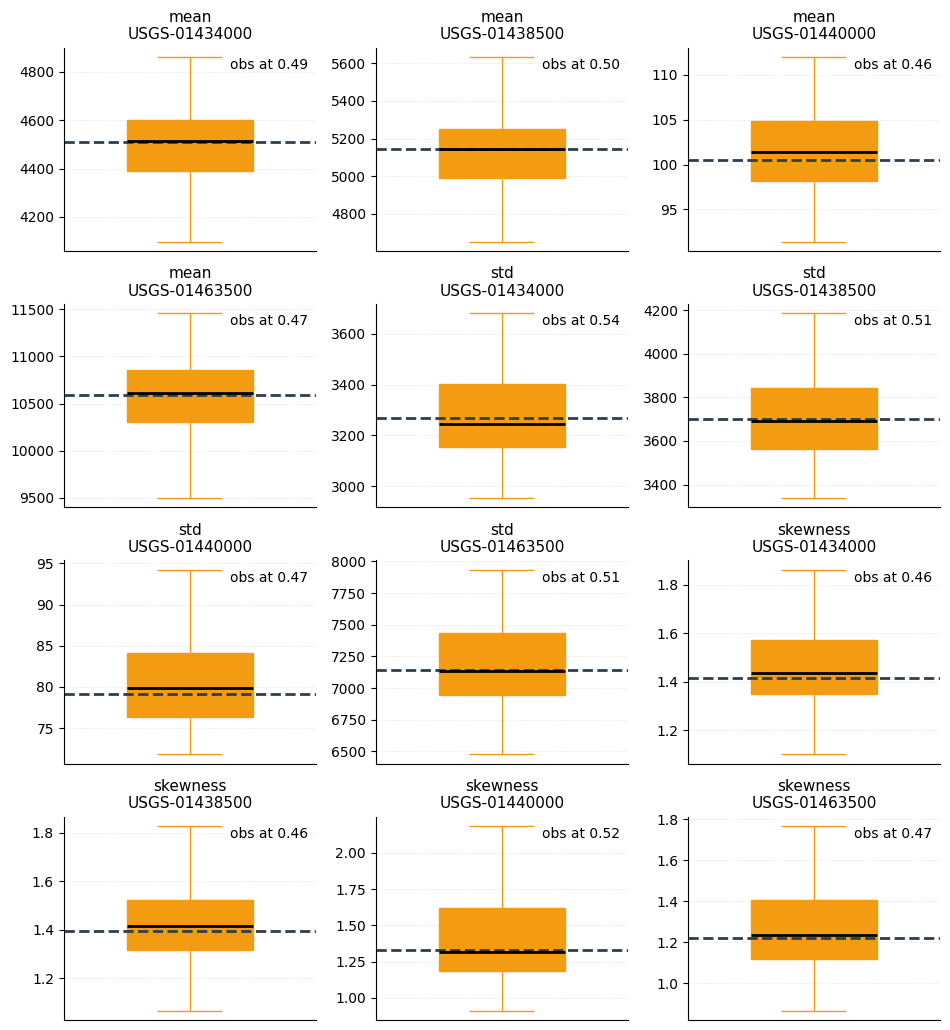

In [10]:
from synhydro.plotting import plot_metric_distributions, plot_metric_curve

fig, axes = plot_metric_distributions(result, metrics=["mean", "std", "skewness"])
fig.savefig(FIG_DIR / "metric_distributions.png", dpi=150, bbox_inches="tight")

Curve metrics (flow duration curve, autocorrelation function, monthly
statistics) show an ensemble band with the observed curve overlaid:

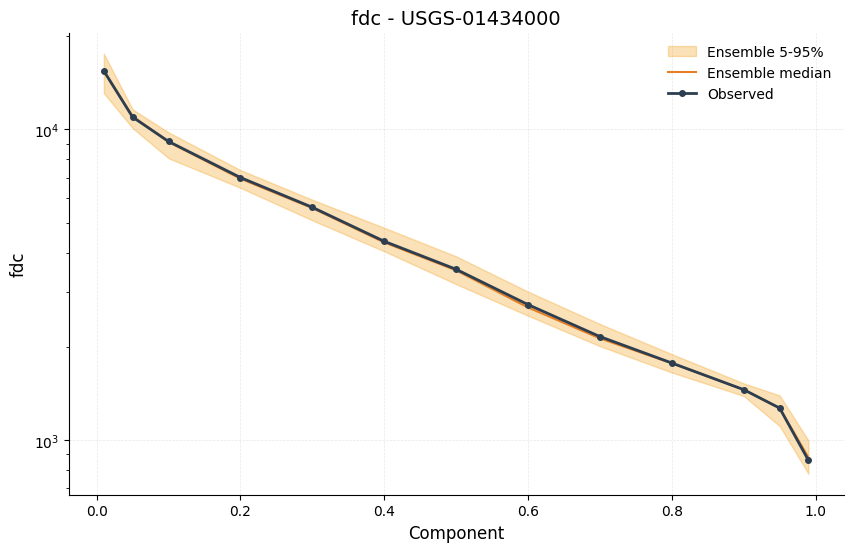

In [11]:
fig, ax = plot_metric_curve(result, "fdc", site=Q_monthly.columns[0])
fig.savefig(FIG_DIR / "fdc_curve.png", dpi=150, bbox_inches="tight")

## The verification panel

`plot_verification_panel` produces a 5-panel figure comparing observed
and synthetic distributions by month, including per-realization
Wilcoxon rank-sum and Levene test p-values. Under a well-performing
generator, roughly 5 percent of realizations fall below the dashed
line at p = 0.05.

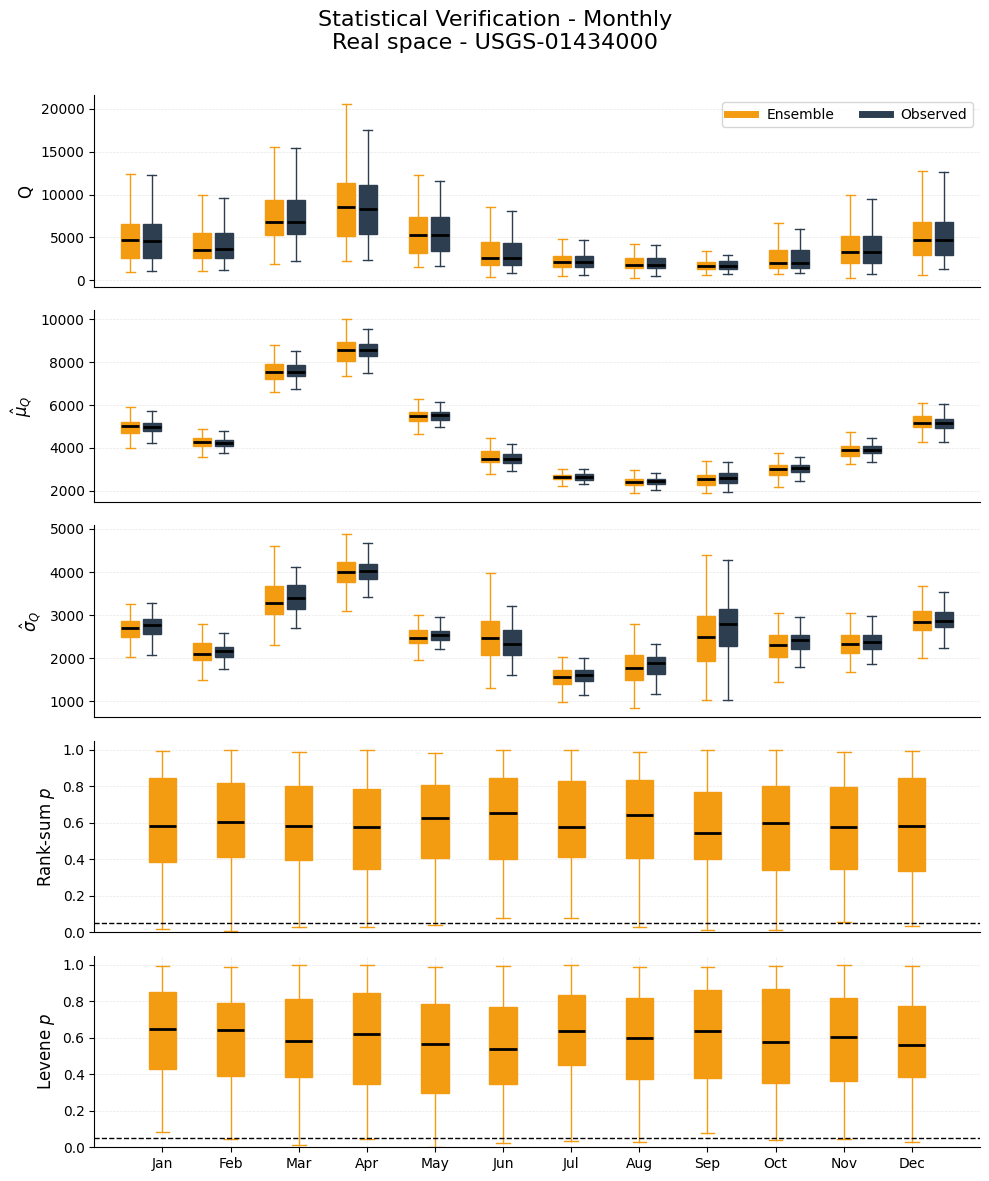

In [12]:
from synhydro.plotting import plot_verification_panel

site = Q_monthly.columns[0]
fig, axes = plot_verification_panel(ensemble, observed=Q_monthly[site], site=site)
fig.savefig(FIG_DIR / "verification_panel.png", dpi=150, bbox_inches="tight")

> **Tip (Log-space comparison):** Streamflow is often right-skewed.
> Comparing statistics of log-transformed flows can reveal differences in
> the lower tail:
> ```python
> fig, axes = plot_verification_panel(
>     ensemble, observed=Q_monthly[site], log_space=True
> )
> ```

## Run validation (drought behavior)

`synhydro.validate` evaluates drought characteristics: run-theory
events below a flow threshold (`threshold_drought`) and events on the
Standardized Streamflow Index (`ssi_drought`). See the
[validation API reference](../../api/validation/).

In [13]:
val = synhydro.validate(ensemble, Q_monthly, metrics="all")
val.summary()

,category,metric,kind,site,component,observed,syn_median,syn_mean,syn_q05,syn_q25,syn_q75,syn_q95,obs_percentile,in_90_band,relative_diff,reject_rate,n_realizations,units
0,threshold_drought,mean_drought_duration,scalar,USGS-01434000,NaN,2.412500,2.239828,2.277333,1.966855,2.122278,2.394542,2.668333,0.757426,True,-0.071574,NaN,100,timesteps
1,threshold_drought,mean_drought_severity,scalar,USGS-01434000,NaN,906.530925,855.846835,859.144677,656.193480,785.894525,948.420047,1049.088248,0.668317,True,-0.055910,NaN,100,flow_cumulative
2,threshold_drought,max_drought_duration,scalar,USGS-01434000,NaN,7.000000,6.000000,6.280000,5.000000,6.000000,7.000000,8.000000,0.816832,True,-0.142857,NaN,100,timesteps
3,threshold_drought,max_drought_severity,scalar,USGS-01434000,NaN,5041.842853,3866.064737,3950.655095,2801.379783,3347.226055,4479.273520,5240.889131,0.896040,True,-0.233204,NaN,100,flow_cumulative
4,threshold_drought,drought_frequency,scalar,USGS-01434000,NaN,0.082988,0.088333,0.087950,0.076583,0.081667,0.092083,0.100083,0.301980,True,0.064417,NaN,100,per_timestep
5,threshold_drought,mean_drought_duration,scalar,USGS-01438500,NaN,2.539474,2.298059,2.322117,2.017186,2.168476,2.474682,2.668889,0.836634,True,-0.095065,NaN,100,timesteps
6,threshold_drought,mean_drought_severity,scalar,USGS-01438500,NaN,1122.163097,1021.502840,1030.194067,822.579959,932.658116,1138.105012,1272.672884,0.727723,True,-0.089702,NaN,100,flow_cumulative
7,threshold_drought,max_drought_duration,scalar,USGS-01438500,NaN,8.000000,6.000000,6.380000,5.000000,6.000000,7.000000,8.000000,0.965347,True,-0.250000,NaN,100,timesteps
8,threshold_drought,max_drought_severity,scalar,USGS-01438500,NaN,5890.017359,4423.898633,4465.353586,3178.304156,3882.181106,5048.880592,5920.940612,0.915842,True,-0.248916,NaN,100,flow_cumulative
9,threshold_drought,drought_frequency,scalar,USGS-01438500,NaN,0.078838,0.085833,0.086350,0.073333,0.081250,0.091667,0.100083,0.193069,True,0.088728,NaN,100,per_timestep


Because drought statistics were not fit by the generator, this is the
stronger test: a generator can verify well and still understate
multi-year drought severity.

## Uncertainty and generator comparison

`bootstrap_metric_ci` puts confidence intervals on ensemble metric
estimates by resampling realizations:

In [14]:
ci = synhydro.bootstrap_metric_ci(result, n_bootstrap=1000, seed=1)
ci.head()

,category,metric,site,component,observed,estimate,ci_lower,ci_upper,relative_diff,rd_ci_lower,rd_ci_upper,n_realizations
0,marginal,mean,USGS-01434000,NaN,4511.235818,4514.525732,4464.884231,4553.394019,0.000729,-0.010275,0.009345,100
1,marginal,mean,USGS-01438500,NaN,5143.336687,5142.809205,5089.878374,5203.050524,-0.000103,-0.010394,0.011610,100
2,marginal,mean,USGS-01440000,NaN,100.506335,101.402675,99.954248,102.296805,0.008918,-0.005493,0.017814,100
3,marginal,mean,USGS-01463500,NaN,10593.393115,10609.626982,10492.505786,10770.708395,0.001532,-0.009524,0.016738,100
4,marginal,std,USGS-01434000,NaN,3269.603194,3245.814727,3222.687505,3310.553646,-0.007276,-0.014349,0.012525,100


`compare_methods` tests whether one generator reproduces observed
statistics better than another, using a paired bootstrap over
realizations:

In [15]:
site = Q_monthly.columns[0]

gen_b = synhydro.ThomasFieringGenerator()
gen_b.fit(Q_monthly[[site]])
ensemble_b = gen_b.generate(n_realizations=100, n_years=50, seed=42)

result_b = synhydro.verify(ensemble_b, Q_monthly[[site]], metrics="all")
comparison = synhydro.compare_methods(result, result_b, seed=1)
comparison[comparison["significant"]]

INFO:synhydro.ThomasFieringGenerator:Validated data: 964 timesteps, 1 sites, period 1945-01-01 00:00:00 to 2025-04-01 00:00:00


INFO:synhydro.ThomasFieringGenerator:Preprocessing complete: 964 months


INFO:synhydro.ThomasFieringGenerator:Fitting complete: 964 months


INFO:synhydro.ThomasFieringGenerator:Generated 100 realizations of 50 years each


,category,metric,site,component,method_a_mae,method_b_mae,diff_estimate,diff_ci_lower,diff_ci_upper,significant,better_method,paired
1,marginal,std,USGS-01434000,<NA>,140.517129,239.630808,-99.113679,-145.175250,-57.187646,True,a,True
2,marginal,cv,USGS-01434000,<NA>,0.021717,0.043314,-0.021597,-0.028958,-0.014287,True,a,True
3,marginal,skewness,USGS-01434000,<NA>,0.151979,0.716057,-0.564078,-0.703603,-0.452419,True,a,True
4,marginal,kurtosis,USGS-01434000,<NA>,0.958836,5.999627,-5.040791,-7.018771,-3.541117,True,a,True
5,marginal,minimum,USGS-01434000,<NA>,87.695126,118.171770,-30.476644,-53.167077,-7.995104,True,a,True
...,...,...,...,...,...,...,...,...,...,...,...,...
152,extremes,annual_min_cv,USGS-01434000,<NA>,0.053238,0.081540,-0.028302,-0.043408,-0.013708,True,a,True
153,spectral,spectral_density,USGS-01434000,>8y,0.025619,0.035466,-0.009847,-0.013236,-0.006025,True,a,True
154,spectral,spectral_density,USGS-01434000,4-8y,0.013904,0.010310,0.003593,0.000674,0.006425,True,b,True
156,spectral,spectral_density,USGS-01434000,1-2y,0.149960,0.136863,0.013096,0.007478,0.018981,True,b,True


## Custom metrics

Any function of a series can join the suite:

In [16]:
from synhydro.verification import register_metric

@register_metric(category="custom", units="flow")
def flow_q25(x):
    """25th percentile of flows."""
    return float(x.quantile(0.25))

result = synhydro.verify(ensemble, Q_monthly, metrics=["marginal", "flow_q25"])

## Next steps

- **Metric definitions and citations** - [Verification API](../../api/verification/)
  and [Validation API](../../api/validation/)
- **Algorithm details** can help diagnose which statistical properties a
  generator is designed to preserve - [Algorithms](../../algorithms/index/)

---

**Previous:** [Working with Ensembles](../04_ensembles/) | **Next:** [Plotting Walkthrough](../06_plotting/)